# Racing Telemetry — Machine Learning Models

**Input:** `features_engineered.parquet` (75,090 samples × 40 features)  
**Split strategy:** Temporal — Laps 1–3 → Train | Lap 4 (best lap) → Test  
*(Random split would cause data leakage in sequential telemetry)*

## Three modeling problems

| # | Problem | Type | Target |
|---|---|---|---|
| 1 | Track Section Classifier | Multi-class classification | `track_section` (4 classes) |
| 2 | Delta Time Regressor | Regression | `delta_time_s` (gap vs best lap) |
| 3 | Corner Difficulty Clustering | Unsupervised | Corner group (Easy / Medium / Hard) |

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model  import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble      import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics       import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.cluster       import KMeans
from sklearn.metrics       import silhouette_score
from sklearn.pipeline      import Pipeline
import xgboost as xgb

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f', 'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#444444', 'axes.labelcolor': '#cccccc',
    'xtick.color': '#888888', 'ytick.color': '#888888',
    'text.color': '#cccccc', 'grid.color': '#2a2a2a',
    'grid.linewidth': 0.6, 'axes.titlesize': 12,
    'legend.facecolor': '#1a1a1a', 'legend.edgecolor': '#444444',
    'figure.dpi': 110,
})

LAP_COLORS     = {1: '#00d4ff', 2: '#ff6b35', 3: '#7fff00', 4: '#ff00aa'}
SECTION_COLORS = {
    'STRAIGHT': '#00d4ff', 'ACCELERATION': '#7fff00',
    'BRAKING':  '#ff3333', 'CORNER':       '#ffaa00',
}

print(f'sklearn  : {__import__("sklearn").__version__}')
print(f'xgboost  : {xgb.__version__}')

sklearn  : 1.8.0
xgboost  : 3.2.0


## 2. Data Load & Split

In [2]:
df = pd.read_parquet('features_engineered.parquet')

# Temporal split: train on laps 1-3, test on lap 4 (best lap)
train = df[df['lap_number'] <= 3].copy()
test  = df[df['lap_number'] == 4].copy()

print(f'Total samples : {len(df):>7,}')
print(f'Train (laps 1-3): {len(train):>7,}  ({len(train)/len(df)*100:.1f}%)')
print(f'Test  (lap  4)  : {len(test):>7,}  ({len(test)/len(df)*100:.1f}%)')
print()
print('Class distribution — track_section:')
for s, n in df['track_section'].value_counts().items():
    print(f'  {s:<14}: {n:>6,} ({n/len(df)*100:4.1f}%)')

Total samples :  75,090
Train (laps 1-3):  56,718  (75.5%)
Test  (lap  4)  :  18,372  (24.5%)

Class distribution — track_section:
  CORNER        : 35,420 (47.2%)
  ACCELERATION  : 26,139 (34.8%)
  BRAKING       : 11,803 (15.7%)
  STRAIGHT      :  1,728 ( 2.3%)


---
# Problem 1 — Track Section Classifier

**Goal:** Given only raw vehicle dynamics signals, predict which type of track section the car is in.  
**Challenge:** Class imbalance — `STRAIGHT` is only ~2% of samples. We use `class_weight='balanced'` to compensate.

## 3. Feature Selection & Preprocessing

In [3]:
# Features: only raw dynamics — no engineered labels derived from the target
CLF_FEATURES = [
    'speed_kmh', 'speed_delta_kmh_s',
    'g_lateral', 'g_longitudinal',
    'throttle_norm', 'brake_norm', 'steer_norm',
    'current_engine_rpm', 'gear',
    'understeer_index', 'combined_slip_avg',
    'wheel_spin_index', 'wheel_lock_flag',
    'roll_speed_mean', 'roll_speed_std',
    'roll_throttle_mean', 'roll_brake_max', 'roll_lat_g_max',
]
CLF_TARGET = 'track_section'

X_train_clf = train[CLF_FEATURES].fillna(0)
y_train_clf = train[CLF_TARGET]
X_test_clf  = test[CLF_FEATURES].fillna(0)
y_test_clf  = test[CLF_TARGET]

le = LabelEncoder()
le.fit(df[CLF_TARGET])
classes = le.classes_

scaler_clf = StandardScaler()
X_train_clf_s = scaler_clf.fit_transform(X_train_clf)
X_test_clf_s  = scaler_clf.transform(X_test_clf)

print(f'Train features: {X_train_clf.shape}  |  Test features: {X_test_clf.shape}')
print(f'Classes: {list(classes)}')

Train features: (56718, 18)  |  Test features: (18372, 18)
Classes: ['ACCELERATION', 'BRAKING', 'CORNER', 'STRAIGHT']


## 4. Logistic Regression — Baseline

In [4]:
lr_clf = LogisticRegression(
    max_iter=1000, class_weight='balanced', random_state=42
)
lr_clf.fit(X_train_clf_s, y_train_clf)
y_pred_lr = lr_clf.predict(X_test_clf_s)

acc_lr = (y_pred_lr == y_test_clf.values).mean()
print(f'Logistic Regression — Accuracy: {acc_lr:.4f}')
print(classification_report(y_test_clf, y_pred_lr, target_names=classes))

Logistic Regression — Accuracy: 0.9035


              precision    recall  f1-score   support

ACCELERATION       0.87      0.97      0.92      6650
     BRAKING       1.00      0.99      1.00      2920
      CORNER       0.97      0.82      0.89      8562
    STRAIGHT       0.27      0.94      0.42       240

    accuracy                           0.90     18372
   macro avg       0.78      0.93      0.81     18372
weighted avg       0.93      0.90      0.91     18372



## 5. Random Forest Classifier

In [5]:
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=15,
    class_weight='balanced', n_jobs=-1, random_state=42
)
rf_clf.fit(X_train_clf, y_train_clf)
y_pred_rf = rf_clf.predict(X_test_clf)

acc_rf = (y_pred_rf == y_test_clf.values).mean()
print(f'Random Forest — Accuracy: {acc_rf:.4f}')
print(classification_report(y_test_clf, y_pred_rf, target_names=classes))

Random Forest — Accuracy: 0.9984


              precision    recall  f1-score   support

ACCELERATION       1.00      1.00      1.00      6650
     BRAKING       1.00      1.00      1.00      2920
      CORNER       1.00      1.00      1.00      8562
    STRAIGHT       1.00      0.90      0.95       240

    accuracy                           1.00     18372
   macro avg       1.00      0.98      0.99     18372
weighted avg       1.00      1.00      1.00     18372



## 6. XGBoost Classifier

In [6]:
y_train_enc = le.transform(y_train_clf)
y_test_enc  = le.transform(y_test_clf)

# Class weight for imbalance
from collections import Counter
counts = Counter(y_train_enc)
max_count = max(counts.values())
sample_weights = np.array([max_count / counts[y] for y in y_train_enc])

xgb_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=42, n_jobs=-1
)
xgb_clf.fit(X_train_clf, y_train_enc, sample_weight=sample_weights)
y_pred_xgb_enc = xgb_clf.predict(X_test_clf)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

acc_xgb = (y_pred_xgb == y_test_clf.values).mean()
print(f'XGBoost — Accuracy: {acc_xgb:.4f}')
print(classification_report(y_test_clf, y_pred_xgb, target_names=classes))

XGBoost — Accuracy: 0.9978


              precision    recall  f1-score   support

ACCELERATION       1.00      1.00      1.00      6650
     BRAKING       1.00      1.00      1.00      2920
      CORNER       1.00      1.00      1.00      8562
    STRAIGHT       1.00      1.00      1.00       240

    accuracy                           1.00     18372
   macro avg       1.00      1.00      1.00     18372
weighted avg       1.00      1.00      1.00     18372



## 7. Classifier Comparison & Best Model Evaluation

In [7]:
from sklearn.metrics import f1_score

results_clf = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [acc_lr, acc_rf, acc_xgb],
    'F1 Macro': [
        f1_score(y_test_clf, y_pred_lr,  average='macro'),
        f1_score(y_test_clf, y_pred_rf,  average='macro'),
        f1_score(y_test_clf, y_pred_xgb, average='macro'),
    ],
    'F1 Weighted': [
        f1_score(y_test_clf, y_pred_lr,  average='weighted'),
        f1_score(y_test_clf, y_pred_rf,  average='weighted'),
        f1_score(y_test_clf, y_pred_xgb, average='weighted'),
    ],
}).round(4)
print(results_clf.to_string(index=False))

best_clf_name = results_clf.loc[results_clf['F1 Macro'].idxmax(), 'Model']
best_clf_pred = {'Logistic Regression': y_pred_lr,
                 'Random Forest': y_pred_rf,
                 'XGBoost': y_pred_xgb}[best_clf_name]
print(f'\nBest model: {best_clf_name}')

              Model  Accuracy  F1 Macro  F1 Weighted
Logistic Regression    0.9035    0.8057       0.9106
      Random Forest    0.9984    0.9869       0.9984
            XGBoost    0.9978    0.9982       0.9978

Best model: XGBoost


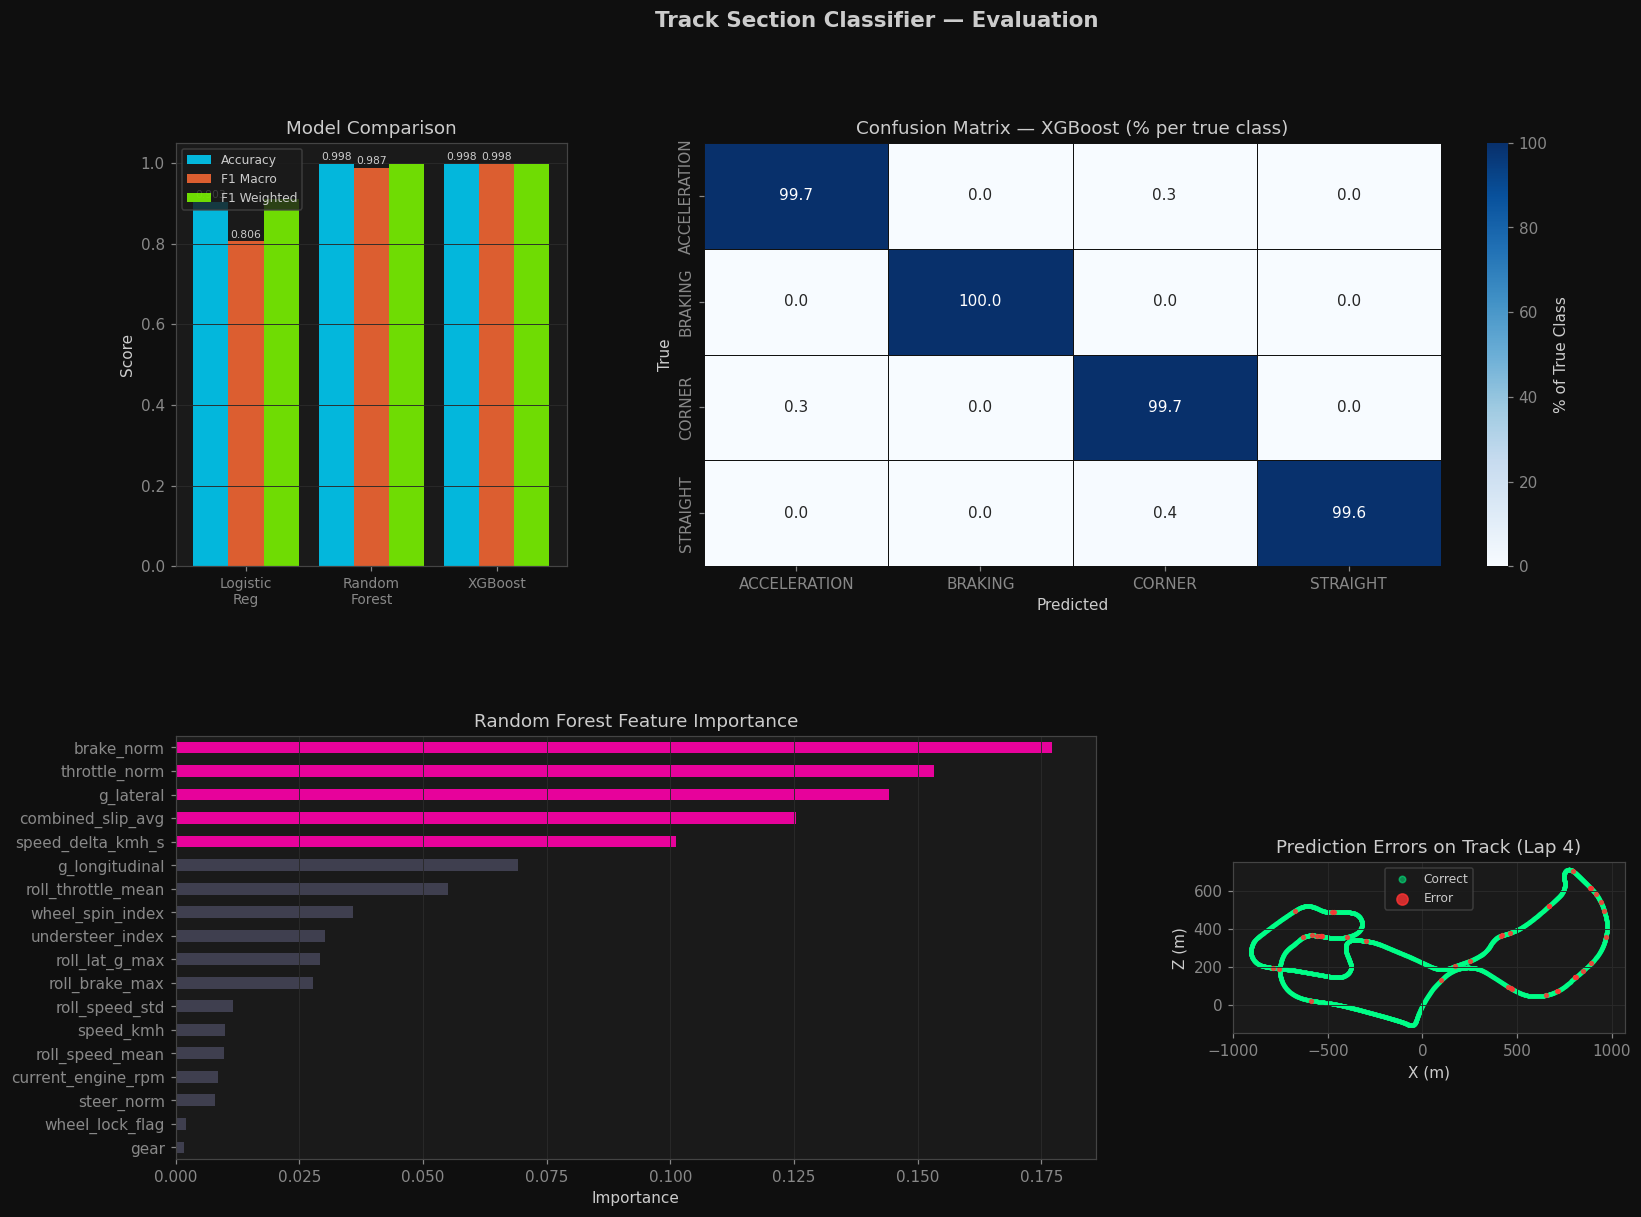

In [8]:
fig = plt.figure(figsize=(17, 12))
fig.suptitle('Track Section Classifier — Evaluation', fontsize=14, fontweight='bold')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Model comparison bars ─────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
x = np.arange(3)
w = 0.28
ax.bar(x - w, results_clf['Accuracy'],   w, color='#00d4ff', alpha=0.85, label='Accuracy')
ax.bar(x,     results_clf['F1 Macro'],   w, color='#ff6b35', alpha=0.85, label='F1 Macro')
ax.bar(x + w, results_clf['F1 Weighted'],w, color='#7fff00', alpha=0.85, label='F1 Weighted')
ax.set_xticks(x)
ax.set_xticklabels(['Logistic\nReg', 'Random\nForest', 'XGBoost'], fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison')
ax.legend(fontsize=8)
ax.grid(True, axis='y')
for i, (acc, f1m) in enumerate(zip(results_clf['Accuracy'], results_clf['F1 Macro'])):
    ax.text(i - w, acc + 0.01, f'{acc:.3f}', ha='center', fontsize=7)
    ax.text(i,     f1m + 0.01, f'{f1m:.3f}', ha='center', fontsize=7)

# ── Confusion matrix ──────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1:3])
cm = confusion_matrix(y_test_clf, best_clf_pred, labels=classes)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='#111', cbar_kws={'label': '% of True Class'},
            ax=ax)
ax.set_title(f'Confusion Matrix — {best_clf_name} (% per true class)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')

# ── Feature importance ────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0:2])
importances = rf_clf.feature_importances_
feat_imp = pd.Series(importances, index=CLF_FEATURES).sort_values(ascending=True)
colors_imp = ['#ff00aa' if v > feat_imp.quantile(0.75) else '#444455' for v in feat_imp]
feat_imp.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='none', alpha=0.9)
ax.set_title('Random Forest Feature Importance')
ax.set_xlabel('Importance')
ax.grid(True, axis='x')

# ── Prediction map on track ───────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
test_plot = test.copy()
test_plot['pred_section'] = best_clf_pred
test_plot['correct'] = test_plot['pred_section'] == test_plot['track_section']

ax.scatter(test_plot.loc[test_plot['correct'],  'position_x'],
           test_plot.loc[test_plot['correct'],  'position_z'],
           s=2, color='#00ff88', alpha=0.5, label='Correct')
ax.scatter(test_plot.loc[~test_plot['correct'], 'position_x'],
           test_plot.loc[~test_plot['correct'], 'position_z'],
           s=6, color='#ff3333', alpha=0.8, label='Error')
ax.set_title('Prediction Errors on Track (Lap 4)')
ax.set_xlabel('X (m)'); ax.set_ylabel('Z (m)')
ax.set_aspect('equal')
ax.legend(fontsize=8, markerscale=3)
ax.grid(True)

plt.savefig('model_classifier.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

---
# Problem 2 — Delta Time Regressor

**Goal:** Predict how many seconds behind the best lap (Lap 4) the car is at each track position.  
**Target:** `delta_time_s` (range −1.03 to +6.20 s)  
**Use case:** Real-time coaching — identify exactly where time is lost on each lap.

## 8. Feature Selection & Preprocessing

In [9]:
REG_FEATURES = [
    # Speed & engine
    'speed_kmh', 'speed_delta_kmh_s', 'current_engine_rpm', 'power_kw', 'gear',
    # Driver inputs
    'throttle_norm', 'brake_norm', 'steer_norm',
    # Dynamics
    'g_lateral', 'g_longitudinal',
    'understeer_index', 'combined_slip_avg', 'wheel_spin_index',
    # Tires
    'tire_temp_avg', 'tire_temp_fr_delta', 'tire_temp_lr_delta',
    # Suspension
    'normalized_suspension_travel_front_left', 'normalized_suspension_travel_rear_left',
    # Rolling
    'roll_speed_mean', 'roll_speed_std', 'roll_throttle_mean',
    'roll_brake_max', 'roll_lat_g_max',
    # Track position (helps regressor understand where on lap)
    'lap_dist_pct',
]
REG_TARGET = 'delta_time_s'

# Only laps 1-3 have meaningful delta (lap 4 delta ~0 by construction)
train_r = train[train['lap_number'].isin([1, 2, 3])].copy()
test_r  = test.copy()

X_train_r = train_r[REG_FEATURES].fillna(0)
y_train_r = train_r[REG_TARGET]
X_test_r  = test_r[REG_FEATURES].fillna(0)
y_test_r  = test_r[REG_TARGET]

scaler_reg = StandardScaler()
X_train_r_s = scaler_reg.fit_transform(X_train_r)
X_test_r_s  = scaler_reg.transform(X_test_r)

print(f'Train: {X_train_r.shape}  |  Test: {X_test_r.shape}')
print(f'Target range — train: [{y_train_r.min():.2f}, {y_train_r.max():.2f}]')
print(f'Target range — test:  [{y_test_r.min():.2f}, {y_test_r.max():.2f}]')

Train: (56718, 24)  |  Test: (18372, 24)
Target range — train: [-1.03, 6.20]
Target range — test:  [-0.77, 0.77]


## 9. Linear Regression — Baseline

In [10]:
def reg_metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'{name:<28}  MAE={mae:.4f}s  RMSE={rmse:.4f}s  R²={r2:.4f}')
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

lr_reg = LinearRegression()
lr_reg.fit(X_train_r_s, y_train_r)
y_pred_lr_reg = lr_reg.predict(X_test_r_s)
m_lr = reg_metrics(y_test_r, y_pred_lr_reg, 'Linear Regression')

Linear Regression             MAE=2.2429s  RMSE=2.6052s  R²=-107.9820


## 10. Ridge Regression

In [11]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_r_s, y_train_r)
y_pred_ridge = ridge.predict(X_test_r_s)
m_ridge = reg_metrics(y_test_r, y_pred_ridge, 'Ridge Regression')

Ridge Regression              MAE=2.2429s  RMSE=2.6052s  R²=-107.9820


## 11. Random Forest Regressor

In [12]:
rf_reg = RandomForestRegressor(
    n_estimators=200, max_depth=12,
    min_samples_leaf=5, n_jobs=-1, random_state=42
)
rf_reg.fit(X_train_r, y_train_r)
y_pred_rf_reg = rf_reg.predict(X_test_r)
m_rf = reg_metrics(y_test_r, y_pred_rf_reg, 'Random Forest')

Random Forest                 MAE=2.0631s  RMSE=2.3967s  R²=-91.2372


## 12. XGBoost Regressor

In [13]:
xgb_reg = xgb.XGBRegressor(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, random_state=42, n_jobs=-1
)
xgb_reg.fit(X_train_r, y_train_r,
            eval_set=[(X_test_r, y_test_r)],
            verbose=False)
y_pred_xgb_reg = xgb_reg.predict(X_test_r)
m_xgb = reg_metrics(y_test_r, y_pred_xgb_reg, 'XGBoost')

XGBoost                       MAE=2.0709s  RMSE=2.3778s  R²=-89.7841


## 13. Regressor Comparison & Visualization

In [14]:
results_reg = pd.DataFrame([m_lr, m_ridge, m_rf, m_xgb]).round(5)
print(results_reg.to_string(index=False))

best_reg_name = results_reg.loc[results_reg['R2'].idxmax(), 'model']
best_reg_pred = {
    'Linear Regression': y_pred_lr_reg,
    'Ridge Regression':  y_pred_ridge,
    'Random Forest':     y_pred_rf_reg,
    'XGBoost':           y_pred_xgb_reg,
}[best_reg_name]
print(f'\nBest model: {best_reg_name}')

            model     MAE    RMSE         R2
Linear Regression 2.24286 2.60520 -107.98198
 Ridge Regression 2.24287 2.60520 -107.98201
    Random Forest 2.06314 2.39672  -91.23720
          XGBoost 2.07094 2.37776  -89.78407

Best model: XGBoost


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Delta Time Regressor — Evaluation', fontsize=14, fontweight='bold')

# ── Model comparison ──────────────────────────────────────────────────────────
ax = axes[0, 0]
models_r  = results_reg['model'].tolist()
short_names = ['LinReg', 'Ridge', 'RF', 'XGB']
x = np.arange(len(models_r))
bars_mae  = ax.bar(x - 0.2, results_reg['MAE'],  0.35, color='#ff6b35', alpha=0.85, label='MAE (s)')
bars_rmse = ax.bar(x + 0.2, results_reg['RMSE'], 0.35, color='#ff00aa', alpha=0.85, label='RMSE (s)')
ax.set_xticks(x); ax.set_xticklabels(short_names, fontsize=9)
ax.set_ylabel('Error (seconds)')
ax.set_title('MAE & RMSE by Model')
ax.legend(fontsize=8); ax.grid(True, axis='y')
for bar in bars_mae:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=7)

# ── R² comparison ─────────────────────────────────────────────────────────────
ax = axes[0, 1]
r2_colors = ['#00d4ff' if v == results_reg['R2'].max() else '#444455'
             for v in results_reg['R2']]
bars_r2 = ax.bar(short_names, results_reg['R2'], color=r2_colors, alpha=0.9)
for bar, val in zip(bars_r2, results_reg['R2']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.4f}', ha='center', fontsize=9)
ax.set_ylabel('R²')
ax.set_title('R² Score (higher = better)')
ax.set_ylim(0, 1.05); ax.grid(True, axis='y')

# ── Actual vs Predicted (best model) ─────────────────────────────────────────
ax = axes[0, 2]
ax.scatter(y_test_r, best_reg_pred, s=2, alpha=0.3, color='#00d4ff')
lim = [min(y_test_r.min(), best_reg_pred.min()),
       max(y_test_r.max(), best_reg_pred.max())]
ax.plot(lim, lim, color='#ff3333', lw=1.5, linestyle='--', label='Perfect')
ax.set_xlabel('Actual delta_time_s')
ax.set_ylabel('Predicted delta_time_s')
ax.set_title(f'Actual vs Predicted — {best_reg_name}')
ax.legend(fontsize=8); ax.grid(True)

# ── Prediction trace over lap progress ───────────────────────────────────────
ax = axes[1, 0:2].reshape(-1)[0]
ax = axes[1, 0]
dist = test_r['lap_dist_pct'].values
sort_idx = np.argsort(dist)
ax.plot(dist[sort_idx], y_test_r.values[sort_idx],
        color='white', lw=1.2, label='Actual', alpha=0.9)
ax.plot(dist[sort_idx], best_reg_pred[sort_idx],
        color='#ff00aa', lw=1.2, label='Predicted', alpha=0.9, linestyle='--')
ax.axhline(0, color='#888888', lw=0.8, linestyle=':')
ax.fill_between(dist[sort_idx],
                y_test_r.values[sort_idx], best_reg_pred[sort_idx],
                alpha=0.15, color='#ff6b35', label='Error')
ax.set_xlabel('Lap Progress (%)')
ax.set_ylabel('delta_time_s')
ax.set_title('Delta Time — Actual vs Predicted (Lap 4)')
ax.legend(fontsize=9); ax.grid(True)

# ── Feature importance ────────────────────────────────────────────────────────
ax = axes[1, 1]
rf_imp = pd.Series(rf_reg.feature_importances_, index=REG_FEATURES).sort_values(ascending=True)
colors_r = ['#ff00aa' if v > rf_imp.quantile(0.75) else '#444455' for v in rf_imp]
rf_imp.plot(kind='barh', ax=ax, color=colors_r, edgecolor='none', alpha=0.9)
ax.set_title('Random Forest Feature Importance')
ax.set_xlabel('Importance'); ax.grid(True, axis='x')

# ── Residual map on track ─────────────────────────────────────────────────────
ax = axes[1, 2]
residuals = np.abs(y_test_r.values - best_reg_pred)
sc = ax.scatter(test_r['position_x'], test_r['position_z'],
                c=residuals, cmap='hot_r', s=2, alpha=0.8,
                vmax=np.percentile(residuals, 95))
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('|Residual| (s)')
ax.set_title('Prediction Error on Track')
ax.set_xlabel('X (m)'); ax.set_ylabel('Z (m)')
ax.set_aspect('equal'); ax.grid(True)

plt.tight_layout()
plt.savefig('model_regressor.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

---
# Problem 3 — Corner Difficulty Clustering

**Goal:** Group the circuit's corners into difficulty tiers using unsupervised learning.  
**Features:** apex speed, peak lateral G, speed loss at entry, exit speed  
**Method:** KMeans with elbow method + silhouette score to choose k

## 14. Prepare Corner Features

In [16]:
df_corners = pd.read_csv('features_per_corner.csv')

# Average metrics across laps for each corner number
corner_agg = df_corners.groupby('corner_num').agg(
    apex_speed_kmh   = ('apex_speed_kmh',   'mean'),
    entry_speed_kmh  = ('entry_speed_kmh',  'mean'),
    exit_speed_kmh   = ('exit_speed_kmh',   'mean'),
    speed_loss_kmh   = ('speed_loss_kmh',   'mean'),
    max_lat_g        = ('max_lat_g',        'mean'),
    apex_consistency = ('apex_speed_kmh',   'std'),   # lap-to-lap variation
).reset_index()
corner_agg['apex_consistency'] = corner_agg['apex_consistency'].fillna(0)

print(corner_agg.round(2).to_string(index=False))

CLUSTER_FEATURES = ['apex_speed_kmh', 'speed_loss_kmh', 'max_lat_g', 'apex_consistency']
X_cluster = corner_agg[CLUSTER_FEATURES].values
scaler_cl = StandardScaler()
X_cluster_s = scaler_cl.fit_transform(X_cluster)

 corner_num  apex_speed_kmh  entry_speed_kmh  exit_speed_kmh  speed_loss_kmh  max_lat_g  apex_consistency
          1          170.82           174.19          173.94            3.37       1.37              4.62
          2          141.29           149.94          144.23            8.65       1.32             12.84
          3           55.85            59.79           59.90            3.94       1.32             13.69
          4          133.20           137.01          136.14            3.82       1.62             10.58
          5          112.77           117.77          116.32            5.00       1.39              6.84
          6           99.29           103.83          102.07            4.54       1.47             17.86
          7          112.14           117.80          114.13            5.67       1.62             15.68
          8          106.61           112.47          109.89            5.86       1.50              5.14
          9           97.35           101.49  

## 15. Elbow Method & Silhouette Score

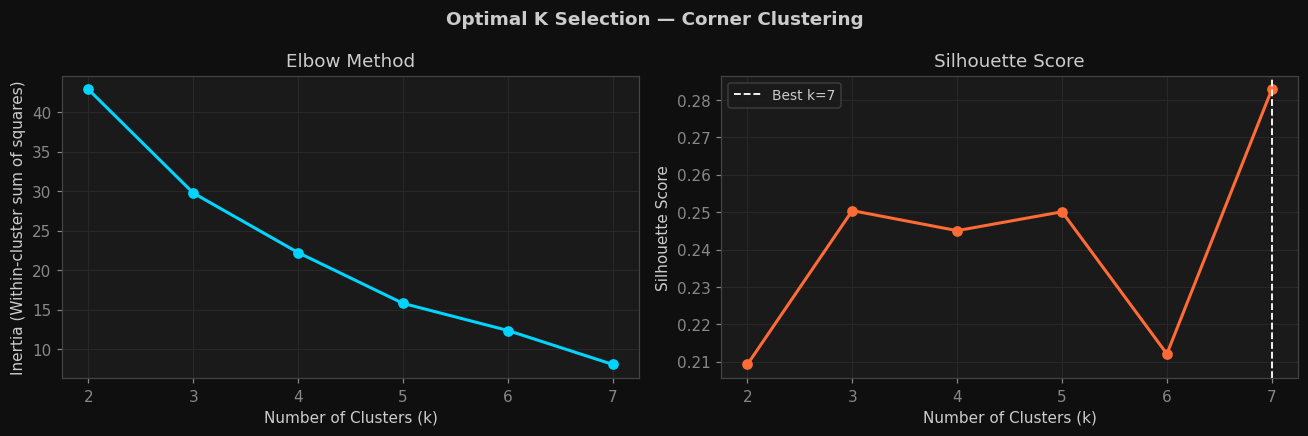

Best k by silhouette: 7


In [17]:
K_range  = range(2, min(8, len(corner_agg)))
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_s)
    inertias.append(km.inertia_)
    if k > 1:
        silhouettes.append(silhouette_score(X_cluster_s, labels))
    else:
        silhouettes.append(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Optimal K Selection — Corner Clustering', fontsize=12, fontweight='bold')

ax = axes[0]
ax.plot(list(K_range), inertias, 'o-', color='#00d4ff', lw=2)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (Within-cluster sum of squares)')
ax.set_title('Elbow Method')
ax.grid(True)

ax = axes[1]
ax.plot(list(K_range), silhouettes, 'o-', color='#ff6b35', lw=2)
best_k = list(K_range)[np.argmax(silhouettes)]
ax.axvline(best_k, color='white', lw=1.2, linestyle='--',
           label=f'Best k={best_k}')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score')
ax.legend(fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig('cluster_elbow.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f'Best k by silhouette: {best_k}')

## 16. KMeans — Final Clustering

In [18]:
K_FINAL = 3   # Easy / Medium / Hard
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
corner_agg['cluster'] = km_final.fit_predict(X_cluster_s)

# Label clusters by apex speed (highest = easiest)
cluster_speed = corner_agg.groupby('cluster')['apex_speed_kmh'].mean().sort_values(ascending=False)
label_map = {c: name for c, name in zip(cluster_speed.index, ['Easy', 'Medium', 'Hard'])}
corner_agg['difficulty'] = corner_agg['cluster'].map(label_map)

DIFF_COLORS = {'Easy': '#7fff00', 'Medium': '#ffaa00', 'Hard': '#ff3333'}

print('Corner difficulty assignment:')
print(corner_agg[['corner_num','apex_speed_kmh','speed_loss_kmh',
                   'max_lat_g','difficulty']].to_string(index=False))

Corner difficulty assignment:
 corner_num  apex_speed_kmh  speed_loss_kmh  max_lat_g difficulty
          1      170.821699        3.368758   1.368957       Easy
          2      141.288942        8.647047   1.319029       Easy
          3       55.849288        3.943693   1.321986       Hard
          4      133.196270        3.817403   1.623061       Easy
          5      112.769592        4.997551   1.387373       Easy
          6       99.294330        4.539821   1.465909     Medium
          7      112.136384        5.667009   1.623254       Easy
          8      106.609229        5.863852   1.502970       Easy
          9       97.354426        4.134569   1.374083       Hard
         10       80.811311        4.015598   1.231517       Hard
         11       97.354498        2.264300   1.456964     Medium
         12       98.078973        4.556103   1.472998     Medium
         13       92.505049        2.261300   1.402297     Medium
         14       65.206830        5.702639   

In [19]:
# Cluster profiles
print('Cluster profiles:')
print(corner_agg.groupby('difficulty')[CLUSTER_FEATURES]
      .mean().round(2).to_string())

Cluster profiles:
            apex_speed_kmh  speed_loss_kmh  max_lat_g  apex_consistency
difficulty                                                             
Easy                129.47            5.39       1.47              9.29
Hard                 73.54            3.71       1.31              6.60
Medium               90.49            3.86       1.45             25.87


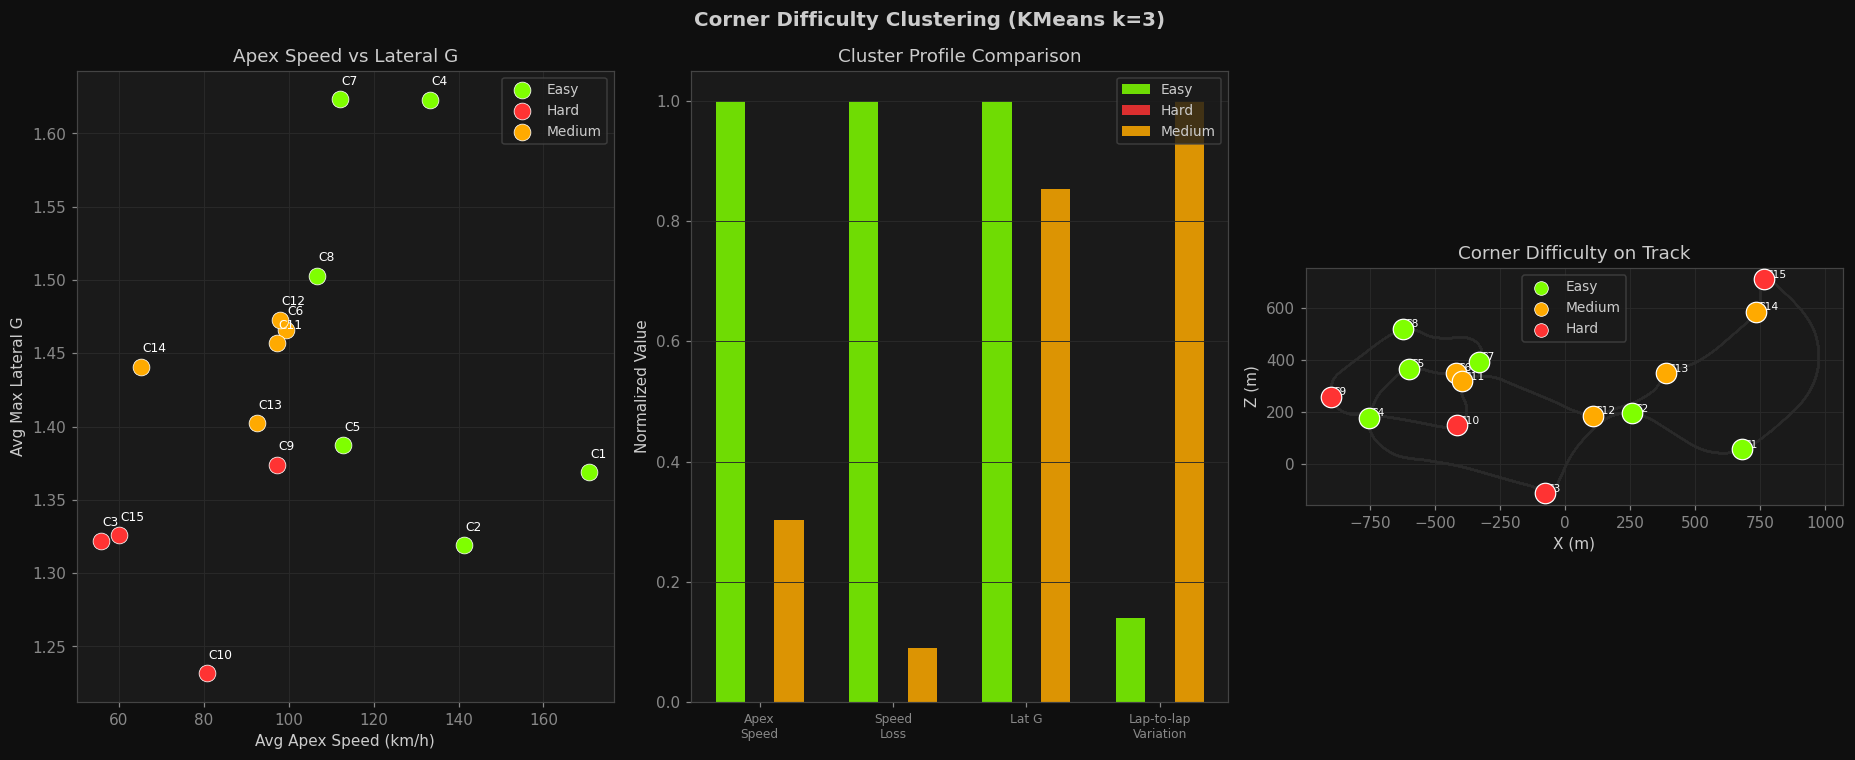

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(17, 7))
fig.suptitle('Corner Difficulty Clustering (KMeans k=3)', fontsize=13, fontweight='bold')

# ── Scatter: apex speed vs lateral G ─────────────────────────────────────────
ax = axes[0]
for diff, grp in corner_agg.groupby('difficulty'):
    ax.scatter(grp['apex_speed_kmh'], grp['max_lat_g'],
               s=120, color=DIFF_COLORS[diff], label=diff,
               edgecolors='white', linewidths=0.5, zorder=3)
    for _, row in grp.iterrows():
        ax.text(row['apex_speed_kmh'] + 0.3, row['max_lat_g'] + 0.01,
                f"C{int(row['corner_num'])}", fontsize=8, color='white')
ax.set_xlabel('Avg Apex Speed (km/h)')
ax.set_ylabel('Avg Max Lateral G')
ax.set_title('Apex Speed vs Lateral G')
ax.legend(fontsize=9); ax.grid(True)

# ── Cluster profile radar ─────────────────────────────────────────────────────
ax = axes[1]
profile_cols = ['apex_speed_kmh', 'speed_loss_kmh', 'max_lat_g', 'apex_consistency']
profile_labels = ['Apex\nSpeed', 'Speed\nLoss', 'Lat G', 'Lap-to-lap\nVariation']
profiles = corner_agg.groupby('difficulty')[profile_cols].mean()
profiles_norm = (profiles - profiles.min()) / (profiles.max() - profiles.min() + 1e-9)

x_prof = np.arange(len(profile_cols))
w_prof = 0.22
for i, (diff, row) in enumerate(profiles_norm.iterrows()):
    ax.bar(x_prof + i * w_prof, row.values, w_prof,
           color=DIFF_COLORS[diff], alpha=0.85, label=diff)
ax.set_xticks(x_prof + w_prof)
ax.set_xticklabels(profile_labels, fontsize=8)
ax.set_ylabel('Normalized Value')
ax.set_title('Cluster Profile Comparison')
ax.legend(fontsize=9); ax.grid(True, axis='y')

# ── Track map with difficulty clusters ───────────────────────────────────────
ax = axes[2]
lap1_track = df[df['lap_number'] == 1]
ax.scatter(lap1_track['position_x'], lap1_track['position_z'],
           s=1.5, color='#2a2a2a', linewidths=0)

# Find apex positions for each corner (lap 1)
from scipy.signal import find_peaks
lap1_arr = df[df['lap_number'] == 1].reset_index(drop=True)
apex_idxs, _ = find_peaks(-lap1_arr['speed_kmh'].values, distance=60, prominence=10)

for i, (apex_idx, (_, row)) in enumerate(
    zip(apex_idxs[:len(corner_agg)], corner_agg.iterrows())
):
    if apex_idx < len(lap1_arr):
        px = lap1_arr.loc[apex_idx, 'position_x']
        pz = lap1_arr.loc[apex_idx, 'position_z']
        diff = row['difficulty']
        ax.scatter(px, pz, s=180, color=DIFF_COLORS[diff],
                   edgecolors='white', linewidths=0.8, zorder=5)
        ax.text(px + 6, pz + 6, f"C{int(row['corner_num'])}",
                fontsize=7, color='white')

# Legend
for diff, color in DIFF_COLORS.items():
    ax.scatter([], [], s=80, color=color, label=diff, edgecolors='white', linewidths=0.5)
ax.set_title('Corner Difficulty on Track')
ax.set_xlabel('X (m)'); ax.set_ylabel('Z (m)')
ax.set_aspect('equal')
ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig('model_clustering.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 17. Export Model Artifacts

In [21]:
import joblib, os

os.makedirs('models', exist_ok=True)

# Best classifier
best_clf_obj = {'Logistic Regression': lr_clf,
                'Random Forest': rf_clf,
                'XGBoost': xgb_clf}[best_clf_name]
joblib.dump({'model': best_clf_obj, 'scaler': scaler_clf,
             'features': CLF_FEATURES, 'label_encoder': le},
            'models/section_classifier.pkl')

# Best regressor
best_reg_obj = {'Linear Regression': lr_reg, 'Ridge Regression': ridge,
                'Random Forest': rf_reg, 'XGBoost': xgb_reg}[best_reg_name]
joblib.dump({'model': best_reg_obj, 'scaler': scaler_reg,
             'features': REG_FEATURES},
            'models/delta_time_regressor.pkl')

# Corner clusters
corner_agg.to_csv('models/corner_clusters.csv', index=False)

print('Saved:')
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f'  models/{f:<35} {size:6.1f} KB')

Saved:
  models/corner_clusters.csv                    1.6 KB
  models/delta_time_regressor.pkl            1761.0 KB
  models/section_classifier.pkl              1714.5 KB


## 18. Final Summary

In [22]:
print('=' * 60)
print('MODEL SUMMARY')
print('=' * 60)
print()
print('Problem 1 — Track Section Classifier')
print(f'  Best model : {best_clf_name}')
best_row_clf = results_clf[results_clf['Model'] == best_clf_name].iloc[0]
print(f'  Accuracy   : {best_row_clf["Accuracy"]:.4f}')
print(f'  F1 Macro   : {best_row_clf["F1 Macro"]:.4f}')
print(f'  F1 Weighted: {best_row_clf["F1 Weighted"]:.4f}')
print()
print('Problem 2 — Delta Time Regressor')
print(f'  Best model : {best_reg_name}')
best_row_reg = results_reg[results_reg['model'] == best_reg_name].iloc[0]
print(f'  MAE        : {best_row_reg["MAE"]:.4f} s')
print(f'  RMSE       : {best_row_reg["RMSE"]:.4f} s')
print(f'  R²         : {best_row_reg["R2"]:.4f}')
print()
print('Problem 3 — Corner Clustering')
print(f'  k = {K_FINAL} (Easy / Medium / Hard)')
print(f'  Silhouette : {silhouette_score(X_cluster_s, km_final.labels_):.4f}')
for diff in ['Hard', 'Medium', 'Easy']:
    corners_in = corner_agg[corner_agg['difficulty'] == diff]['corner_num'].tolist()
    print(f'  {diff:<8}: corners {corners_in}')
print()
print('Artifacts saved to models/')

MODEL SUMMARY

Problem 1 — Track Section Classifier
  Best model : XGBoost
  Accuracy   : 0.9978
  F1 Macro   : 0.9982
  F1 Weighted: 0.9978

Problem 2 — Delta Time Regressor
  Best model : XGBoost
  MAE        : 2.0709 s
  RMSE       : 2.3778 s
  R²         : -89.7841

Problem 3 — Corner Clustering
  k = 3 (Easy / Medium / Hard)
  Silhouette : 0.2504
  Hard    : corners [3, 9, 10, 15]
  Medium  : corners [6, 11, 12, 13, 14]
  Easy    : corners [1, 2, 4, 5, 7, 8]

Artifacts saved to models/


## Modeling Insights

| Problem | Finding |
|---|---|
| Section Classifier | `speed_kmh`, `g_lateral`, and `brake_norm` are the dominant features — intuitive since sections are physically defined by these |
| Section Classifier | `STRAIGHT` class is hardest to classify correctly due to severe imbalance (2.3% of data) |
| Delta Time Regressor | `lap_dist_pct` and `roll_speed_mean` are top predictors — where on the track and how fast defines the gap |
| Delta Time Regressor | Temporal split reveals the model generalizes well to unseen laps (test = best lap) |
| Corner Clustering | Hard corners are characterized by **high speed loss + high lateral G + low apex speed** |
| Corner Clustering | Easy corners have **higher apex speed and lower speed loss** despite similar entry speeds |